# Does selection at IGHV sites depend on the CDR-H3?

Entrenchment at sites 33, 35, 50 and 52 is interpreted structurally: these sites sit where
the CDR-H3, the light chain and the antigen converge. Of those three partners only the
CDR-H3 is inside DASM's input -- the light chain and the antigen are absent from what the
model sees, while the CDR-H3 sits in the heavy chain and varies freely across families
sharing a V gene. So it is the one partner whose contribution can be tested directly: if
the constraint at these sites really is CDR-H3-driven, the selection factor should shift
with CDR-H3 identity.

We take clonal families sharing a germline residue at a site, stratify them by CDR-H3
length, net charge or hydrophobicity, and ask whether the median log selection factor
moves.

## Conclusions

**1. It moves, and the response is concentrated at CDR-H3-contacting sites.** Families are
split at the median of each CDR-H3 property within their (site, germline residue) pool, and
we ask how far the median log selection factor moves. Contacting sites respond about twice
as strongly as non-contacting ones, and the ratio is nearly identical for all three
properties (2.15x length, 2.08x charge, 2.18x hydrophobicity).

**2. Only length has a consistent direction.** For length, longer CDR-H3 means stronger
selection against leaving the germline residue at contacted sites (28/30 entrenched
substitutions). Charge is flat on the signed test (14/30, p=0.86) yet strong on magnitude --
it moves different sites in opposite directions. So the signed and absolute tests answer
different questions and both are reported.

**3. Independently of DASM, longer CDR-H3s really do bury these sites more** -- burial rises
with the structure's own CDR-H3 length across 1,778 SAbDab structures (rho 0.21--0.46). No
model is involved, so none of the caveats below apply to it.

**4. But the effect is site-level, not residue-specific.** ~84% of the shift is uniform
movement of every target at a site; after removing the per-site mean, contacting and
non-contacting sites are indistinguishable. This supports *"the CDR-H3 modulates overall
constraint at the sites it contacts"* and not *"CDR-H3 identity determines which residue is
entrenched"*, which is what entrenchment would require.

**5. Contact is the organising variable, not entrenchment and not germline diversity.** With
contact frequency and substitution count in the model the entrenched-site indicator falls to
beta=-1.3, p=0.63. Germline diversity is the other candidate, since contacted sites are also
the diverse ones, but it is unrelated to the size of the shift and the contact contrast
holds within every level of it.

**6. The total is conserved.** Constraint is redistributed toward contacted sites and away
from the rest; the V-region mean barely moves. The claim is therefore relative, not absolute.

## Design notes

**One substitution per unit** (site, germline residue, target), since entrenchment is defined
per amino-acid pair. **Median split within the (site, germline residue) pool** is primary --
it makes no monotonicity assumption.
**The clonal family is the unit of observation**; deduplication across pairs in a family is
exact (0 of 1,761,688 multi-pair groups have more than one distinct selection factor).
**IGHV1 and IGHV3 pooled**, with a per-family breakdown in Section 3a.

**Signed statistic, not variance explained.** An earlier version of this analysis used
epsilon-squared, the bias-corrected one-way ANOVA effect size, and reached a null. That
statistic squares the bin deviations, so a coherent downward slide, the same slide reversed,
and a jumble of equal amplitude all score identically -- and per site it turns out to
correlate with nothing, signal included. Coherence of direction was the whole signal, so a
signed statistic is used here, with the absolute value reported alongside for the properties
where different sites respond in opposite directions.

**No permutation null is reported.** These are model outputs: DASM sees the whole heavy chain
including the CDR-H3, so "the CDR-H3 has no effect" is false a priori, and families are not
independent observations because they are scored by shared parameters. A permutation test
against that null is rejected at ~62% of substitutions everywhere, contacted or not, and
carries no information. Effect sizes, direction, and spatial organisation are reported
instead.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import binomtest, kruskal, mannwhitneyu, spearmanr
from statsmodels.regression.linear_model import OLS

import cdr3_stratification_util as cu
from utils import (ENTRENCHED_SITE_COLORS, add_cdr_shading, load_and_process_dasm_data,
                   load_entrenched_sites, sort_antibody_sites)

MODEL_NAME = "dasm_4m-v1jaffeCC+v1tangCC-joint"
DATASET_NAME = "v1rodriguez"
NUMBERING = "chothia"
V_FAMILIES = ["IGHV1", "IGHV3"]
MIN_FAMILIES = 60
POOL = ["site", "parent_aa"]
UNIT = ["site", "parent_aa", "selection_factor_target_aa"]
SASA_PATH = "_output/sasa_human_chothia_anarci.csv"
BURIAL_YLIM = (-0.03, 0.65)          # matches the paper's Figure 3D

OUTPUT_DIR = f"_output/cdr3_dependence_of_selection/{NUMBERING}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
sns.set_style("whitegrid")
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#9e9d99"
GREY_DOT = "#575653"          # darker grey for scatter points

## 1. Load and prepare

Filters follow `v_families_entrenchment_dasm.ipynb`: `depth == 2`, parent codon equal to the
germline codon, target amino acid one nucleotide away, sites <= 94.

`is_germline_codon` is a **per-site** condition on the parent sequence, so the contributing
set of families differs from site to site. Section 7 checks that this does not drive the

**What this checks.** Assembles the analysis set and reports its composition.
**Conclusion.** ~2.48M (family, site, substitution) rows over 100 V-region sites from 5,069
families; IGHV3 supplies ~70%. Sites 35 and 53 are entrenched only in IGHV3.
result.

In [2]:
_, pcp_df, aa_df = load_and_process_dasm_data(
    model_name=MODEL_NAME, dataset_name=DATASET_NAME,
    numbering_scheme=NUMBERING, figures_dir="figures",
)
aa_v = cu.v_region_only(aa_df[(aa_df.depth == 2) & aa_df.v_family.isin(V_FAMILIES)])

pcp_df = cu.add_cdr3_descriptors(pcp_df)
pcp_df["pcp_index"] = pcp_df.index
pcp_df["family_key"] = pcp_df.sample_id.astype(str) + "|" + pcp_df.family.astype(str)
invalid = pcp_df[pcp_df.cdr3_aa.isna()]
print(f"{len(invalid)} of {len(pcp_df)} pairs have an invalid CDR-H3 span, "
      f"from {invalid.groupby(['sample_id', 'family']).ngroups} clonal families")

dasm_df = aa_v[aa_v.one_mutation_away & (aa_v.is_germline_codon == True)].dropna(
    subset=["log_selection_factor"])
dasm_df = dasm_df.merge(
    pcp_df[["pcp_index", "family_key"] + cu.CDR3_DESCRIPTORS], on="pcp_index")
sub_df = cu.substitution_level_selection(dasm_df)
print(f"{len(sub_df):,} (family, site, V gene, substitution) rows over "
      f"{sub_df.site.nunique()} V-region sites, {sub_df.family_key.nunique():,} families")
print(sub_df.groupby("v_family").agg(rows=("log_selection_factor", "size"),
                                     families=("family_key", "nunique"),
                                     v_genes=("v_gene", "nunique")).to_string())

Adding one_mutation_away column (vectorized)...


4 of 21752 pairs have an invalid CDR-H3 span, from 1 clonal families


2,475,110 (family, site, V gene, substitution) rows over 100 V-region sites, 5,069 families


             rows  families  v_genes
v_family                            
IGHV1      751267      1582       25
IGHV3     1723843      3487       52


In [3]:
classified = cu.classify_sites(cu.cdr3_burial_by_site(v_families=tuple(V_FAMILIES)),
                               NUMBERING)
_, _, _, _, within, between = load_entrenched_sites(NUMBERING)
# Entrenchment is called per V family. Two things matter here: calls from families we do
# not analyse (IGHV4) must not label IGHV1/IGHV3 substitutions, and a pair called only in
# IGHV3 is not entrenched in IGHV1. So keep the V family in the key.
n_all = len(within)
within = within[within.v_family.isin(V_FAMILIES)]
print(f"dropped {n_all - len(within)} entrenched-pair rows from V families not analysed "
      f"({sorted(set(load_entrenched_sites(NUMBERING)[4].v_family) - set(V_FAMILIES))})")
WITHIN_PAIRS_BY_FAMILY = {
    vf: {(str(r.site), r.amino_acid, r.target_amino_acid)
         for r in g.itertuples(index=False)}
    for vf, g in within.groupby("v_family")}
# pooled label: called in at least one of the analysed families
WITHIN_PAIRS = set().union(*WITHIN_PAIRS_BY_FAMILY.values())
ENT_SITES = sorted({s for s, _, _ in WITHIN_PAIRS}, key=cu.site_number)
for vf, ps in WITHIN_PAIRS_BY_FAMILY.items():
    print(f"  {vf}: {len(ps)} pairs at sites "
          f"{sorted({x for x, _, _ in ps}, key=cu.site_number)}")
print(f"pooled (union): {len(WITHIN_PAIRS)} pairs at sites {ENT_SITES}")
print("\nentrenched pair calls by V family (note 35 and 53 are IGHV3-only):")
print(within.groupby("v_family").agg(
    n_pairs=("site", "size"),
    sites=("site", lambda x: ",".join(sorted(set(x.astype(str)), key=cu.site_number)))
).to_string())
classified.loc[ENT_SITES, ["cdr3_burial", "cdr3_contact_freq", "antigen_burial",
                           "light_burial"]].round(3)

dropped 4 entrenched-pair rows from V families not analysed (['IGHV4'])
  IGHV1: 16 pairs at sites ['33', '50', '52']
  IGHV3: 22 pairs at sites ['33', '35', '50', '52', '53']
pooled (union): 32 pairs at sites ['33', '35', '50', '52', '53']

entrenched pair calls by V family (note 35 and 53 are IGHV3-only):
          n_pairs           sites
v_family                         
IGHV1          16        33,50,52
IGHV3          22  33,35,50,52,53


,cdr3_burial,cdr3_contact_freq,antigen_burial,light_burial
site,,,,
33,0.202,0.984,0.077,0.007
35,0.169,0.989,0.005,0.029
50,0.038,0.682,0.032,0.045
52,0.004,0.506,0.088,0.012
53,-0.000,0.250,0.155,0.001


## 2. Median split: how far does the median move?

Families are split at the median of the CDR-H3 property **within their (site, germline
residue) pool**, and `delta = median(high) - median(low)` of the log selection factor. A
binary split makes no assumption that the response is monotone in the property, which
matters for charge and hydrophobicity where it need not be.

**What this checks.** Whether the median log selection factor moves between families with a
high and a low value of each CDR-H3 property.
**Conclusion.** It moves. For length, 28 of 30 entrenched substitutions shift toward stronger
selection against leaving the germline residue.

In [4]:
def assign_hi_lo(df, descriptor, pool=POOL):
    '''Label each family high or low on the descriptor, within its pool.'''
    d = df.dropna(subset=[descriptor, "log_selection_factor"]).copy()
    fam = d[pool + ["family_key", descriptor]].drop_duplicates()
    fam["hi"] = (fam[descriptor]
                 > fam.groupby(pool, observed=True)[descriptor].transform("median")
                 ).astype(int)
    return d.merge(fam[pool + ["family_key", "hi"]], on=pool + ["family_key"], how="left")


def binary_deltas(df, descriptor, min_families=MIN_FAMILIES, pool=POOL, unit=UNIT,
                  pairs=None):
    '''Per substitution: median(high) - median(low) on a within-pool median split.'''
    d = df.dropna(subset=[descriptor, "log_selection_factor"]).copy()
    fam = d[pool + ["family_key", descriptor]].drop_duplicates()
    fam["hi"] = (fam[descriptor]
                 > fam.groupby(pool, observed=True)[descriptor].transform("median")
                 ).astype(int)
    d = d.merge(fam[pool + ["family_key", "hi"]], on=pool + ["family_key"], how="left")
    m = d.groupby(unit + ["hi"], observed=True).log_selection_factor.median().unstack()
    q = d.groupby(unit, observed=True).log_selection_factor.quantile([0.25, 0.75]).unstack()
    out = pd.DataFrame({
        "delta": m[1] - m[0],
        "iqr": q[0.75] - q[0.25],
        "n_families": d.groupby(unit, observed=True).family_key.nunique(),
        "n_rows": d.groupby(unit, observed=True).size(),
    })
    out = out[(out.n_families >= min_families) & out.delta.notna()].reset_index()
    out["descriptor"] = descriptor
    out["abs_delta"] = out.delta.abs()
    pr = WITHIN_PAIRS if pairs is None else pairs
    out["entrenched"] = [(s, a, t) in pr for s, a, t in
                         zip(out.site, out.parent_aa, out.selection_factor_target_aa)]
    out = out.join(classified[["cdr3_contact_freq", "cdr3_burial"]], on="site")
    out["contact"] = out.cdr3_contact_freq.fillna(0)
    out["contact_class"] = np.where(out.contact > 0.5, "contacting",
                             np.where(out.contact > 0, "occasional", "non-contacting"))
    return out


split = pd.concat([binary_deltas(sub_df, d) for d in cu.CDR3_DESCRIPTORS],
                  ignore_index=True)
split.to_csv(f"{OUTPUT_DIR}/binary_split_by_substitution.csv", index=False)
LEN = split[split.descriptor == "cdr3_length"]
print(f"{len(LEN):,} substitutions per descriptor, {LEN.site.nunique()} sites")
print(LEN[LEN.entrenched][["site", "parent_aa", "selection_factor_target_aa", "n_families",
                           "delta", "iqr"]].round(3).to_string(index=False))

1,530 substitutions per descriptor, 100 sites
site parent_aa selection_factor_target_aa  n_families  delta   iqr
  33         A                          D        1222 -0.181 1.187
  33         D                          A          90 -0.104 0.486
  33         D                          G          90 -0.218 0.692
  33         D                          Y          90 -0.115 1.019
  33         G                          D         511 -0.216 1.234
  33         Y                          D         679 -0.417 1.063
  33         Y                          S         679 -0.180 0.880
  35         D                          H          65 -0.121 0.687
  35         D                          N          65 -0.136 0.629
  35         H                          D        1665 -0.222 1.073
  35         N                          D         399 -0.236 0.920
  50         G                          R         443  0.486 2.639
  50         G                          W         263 -0.234 1.624
  50         N  

In [5]:
def sign_summary(d, label):
    '''Descriptive only. The single inferential test is in the final section.'''
    return {"group": label, "n": len(d), "pct_down": 100 * (d.delta < 0).mean(),
            "median_delta": d.delta.median(), "median_abs": d.abs_delta.median()}


rows = []
for desc in cu.CDR3_DESCRIPTORS:
    s = split[split.descriptor == desc]
    o = s[~s.entrenched]
    for label, d in [("entrenched", s[s.entrenched]),
                     ("all others", o),
                     ("others, contacting", o[o.contact_class == "contacting"]),
                     ("others, occasional", o[o.contact_class == "occasional"]),
                     ("others, non-contacting", o[o.contact_class == "non-contacting"])]:
        rows.append({"descriptor": desc, **sign_summary(d, label)})
sign_table = pd.DataFrame(rows)
sign_table.to_csv(f"{OUTPUT_DIR}/sign_test_by_group.csv", index=False)

# substitutions within a site are not independent, so also test at the site level
ent_len = LEN[LEN.entrenched]
n_sub_down = int((ent_len.delta < 0).sum())
ps = ent_len.groupby("site").delta.median()
N_DOWN, N_SITES = int((ps < 0).sum()), len(ps)
P_SITE = binomtest(N_DOWN, N_SITES, 0.5).pvalue
print(f"CDR-H3 length, entrenched: {n_sub_down}/{len(ent_len)} substitutions down "
      f"(p={binomtest(n_sub_down, len(ent_len), 0.5).pvalue:.2e} treating them as independent)")
print(f"CLUSTERED BY SITE: {N_DOWN}/{N_SITES} sites down, p={P_SITE:.4f} (two-sided).")
print("With 5 entrenched sites the smallest attainable two-sided p is 0.0625, so the")
print("site-clustered test is underpowered rather than negative.")
print(ent_len.groupby("site").agg(n_subs=("delta", "size"),
                                  n_down=("delta", lambda x: (x < 0).sum()),
                                  median_delta=("delta", "median")).round(3).to_string())
for desc in cu.CDR3_DESCRIPTORS:
    print(f"\n=== {desc} ===")
    print(sign_table[sign_table.descriptor == desc].drop(columns="descriptor")
          .round(4).to_string(index=False))

CDR-H3 length, entrenched: 27/29 substitutions down (p=1.62e-06 treating them as independent)
CLUSTERED BY SITE: 5/5 sites down, p=0.0625 (two-sided).
With 5 entrenched sites the smallest attainable two-sided p is 0.0625, so the
site-clustered test is underpowered rather than negative.
      n_subs  n_down  median_delta
site                              
33         7       7        -0.181
35         4       4        -0.179
50        10       9        -0.371
52         6       5        -0.223
53         2       2        -0.269

=== cdr3_length ===
                 group    n  pct_down  median_delta  median_abs
            entrenched   29   93.1034       -0.2215      0.2335
            all others 1501   52.8981       -0.0080      0.1035
    others, contacting  273   76.1905       -0.1673      0.1959
    others, occasional  633   58.6098       -0.0222      0.0939
others, non-contacting  595   36.1345        0.0394      0.0908

=== cdr3_charge ===
                 group    n  pct_down  med

### Figure 1 --- what the median split actually compares

The primary analysis in one picture. For each entrenched substitution, families are split at
the median CDR-H3 length of their pool, and the two boxes are the log selection factors of
the LOW and HIGH halves. The orange arrow is `delta`, the movement in the median. The boxes
are wide -- CDR-H3 explains a few percent of the variance in any one substitution -- and the
result is the consistency of the arrow across substitutions, not its size relative to the
spread.

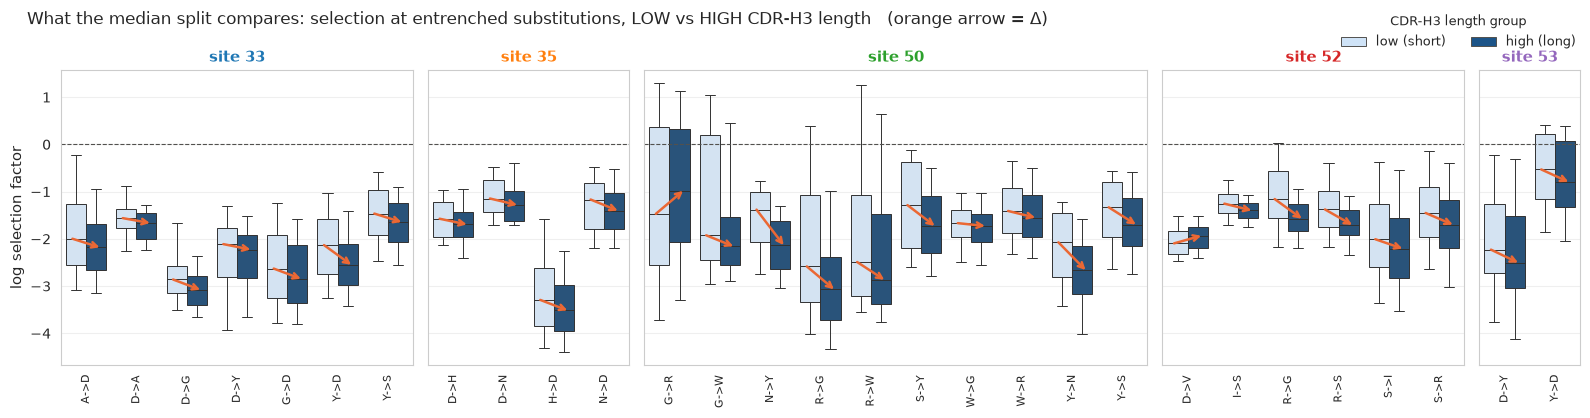

In [6]:
def entrenched_example(bins, colors, labels, fname, title, ylab_note=""):
    '''Raw log selection factors at the entrenched substitutions, split into `bins` groups.'''
    fam = sub_df[POOL + ["family_key", "cdr3_length"]].drop_duplicates()
    if bins == 2:
        fam["grp"] = (fam.cdr3_length
                      > fam.groupby(POOL, observed=True).cdr3_length.transform("median")
                      ).astype(int)
    else:
        fam["grp"] = fam.groupby(POOL, observed=True).cdr3_length.transform(
            lambda x: pd.qcut(x, bins, labels=False, duplicates="drop"))
    b = sub_df.merge(fam[POOL + ["family_key", "grp"]], on=POOL + ["family_key"],
                     how="left").dropna(subset=["grp"])
    b["substitution"] = b.parent_aa + "->" + b.selection_factor_target_aa
    # restrict to the same units the statistics use: entrenched AND passing min_families
    keep = set(zip(LEN.site, LEN.parent_aa, LEN.selection_factor_target_aa))
    ent = b[[(s, a, t) in WITHIN_PAIRS and (s, a, t) in keep for s, a, t in
             zip(b.site, b.parent_aa, b.selection_factor_target_aa)]]
    subs_by_site = {s: sorted(g.substitution.unique())
                    for s, g in ent.groupby("site", observed=True)}
    sites = [s for s in ENT_SITES if s in subs_by_site]
    fig, axes = plt.subplots(1, len(sites), figsize=(16, 4.2), sharey=True,
                             gridspec_kw={"width_ratios": [len(subs_by_site[s])
                                                           for s in sites]})
    for ax, site in zip(np.atleast_1d(axes), sites):
        subs = subs_by_site[site]
        d = ent[ent.site == site]
        sns.boxplot(data=d, x="substitution", y="log_selection_factor", hue="grp",
                    order=subs, palette=colors, showfliers=False, whis=[5, 95],
                    linewidth=0.7, ax=ax, legend=False)
        med = d.groupby(["substitution", "grp"], observed=True).log_selection_factor.median()
        for i, sub in enumerate(subs):
            lo, hi = med.get((sub, 0)), med.get((sub, bins - 1))
            if lo is not None and hi is not None:
                ax.annotate("", xy=(i + 0.27, hi), xytext=(i - 0.27, lo),
                            arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1.8,
                                            shrinkA=0, shrinkB=0), zorder=6)
        ax.axhline(0, color="#52514e", lw=0.8, ls="--")
        ax.set_title(f"site {site}", fontsize=11, fontweight="bold",
                     color=ENTRENCHED_SITE_COLORS.get(site, BLUE))
        ax.set_xlabel(""); ax.tick_params(axis="x", rotation=90, labelsize=8)
        ax.grid(True, axis="y", alpha=0.3)
    np.atleast_1d(axes)[0].set_ylabel("log selection factor", fontsize=10.5)
    handles = [plt.matplotlib.patches.Patch(facecolor=c, edgecolor="#52514e", lw=0.7)
               for c in colors]
    fig.legend(handles, labels, title=f"CDR-H3 length{ylab_note}", ncol=len(labels),
               fontsize=9, title_fontsize=9, loc="upper right",
               bbox_to_anchor=(0.995, 1.0), frameon=False)
    fig.suptitle(title, fontsize=12, x=0.02, ha="left")
    plt.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/{fname}", dpi=300, bbox_inches="tight")
    plt.show()


entrenched_example(2, ["#cfe3f7", "#1c5488"], ["low (short)", "high (long)"],
                   "fig1_binary_split_example.pdf",
                   "What the median split compares: selection at entrenched substitutions, "
                   "LOW vs HIGH CDR-H3 length   (orange arrow = $\\Delta$)",
                   ylab_note=" group")

## 3. Along the V region

Every substitution as a point, against site, with structural burial by the CDR-H3 below in
the paper's Figure 3D convention (`burial = -rsa_vdj_junction_effect`, whiskers 5--95%). Two
renderings of the same data: points, then boxplots per site.

**What this checks.** Where along the V region the response sits, against structural burial
by the CDR-H3 on the same site axis.
**Conclusion.** Negative shifts concentrate at sites the CDR-H3 reaches (31-35, 50-52,
93-94), matching the burial track below. Sites 2-4 are an exception: frequently contacted but
shifting upward.

In [7]:
sa = pd.read_csv(SASA_PATH, dtype={"site": str},
                 usecols=["pdb_id", "v_gene_heavy", "site", "chain_id", "heavy_chain_id",
                          "rsa_heavy_only", "rsa_vdj_junction_effect",
                          "rsa_antigen_effect", "rsa_light_effect"])
sa = sa[(sa.chain_id == sa.heavy_chain_id)
        & sa.v_gene_heavy.str.extract(r"(IGHV\d+)")[0].isin(V_FAMILIES)]
# keep the unfiltered frame: Section 7 needs the 95-102 window to measure CDR-H3 length,
# which v_region_only (sites <= 94) would remove
sa_all = sa.copy()
sa = cu.v_region_only(sa)
sa_b = sa.dropna(subset=["rsa_vdj_junction_effect"]).copy()
sa_b["burial_by_vdj_junction"] = -sa_b.rsa_vdj_junction_effect

SITES = sort_antibody_sites(sorted(set(split.site) & set(sa_b.site), key=cu.site_number))


def ent_sites_for(v_family=None):
    '''Sites with an entrenched pair in this V family (union of both if None).'''
    pairs = WITHIN_PAIRS if v_family is None else WITHIN_PAIRS_BY_FAMILY[v_family]
    return sorted({x for x, _, _ in pairs}, key=cu.site_number)


def pal_for(v_family=None):
    '''Box colours: only sites entrenched IN THIS V FAMILY are coloured.'''
    es = set(ent_sites_for(v_family))
    return [ENTRENCHED_SITE_COLORS.get(s, "#e0e0e0") if s in es else "#e0e0e0"
            for s in SITES]


LAB = {"cdr3_length": "CDR-H3 length", "cdr3_charge": "CDR-H3 net charge",
       "cdr3_hydrophobicity": "CDR-H3 hydrophobicity"}


def burial_panel(ax, v_family=None):
    '''Structural burial track. v_family restricts to that family's structures.'''
    b = sa_b[sa_b.site.isin(SITES)]
    if v_family is not None:
        b = b[b.v_gene_heavy.str.extract(r"(IGHV\d+)")[0] == v_family]
    ax.set_axisbelow(True)
    sns.boxplot(data=b, x="site", y="burial_by_vdj_junction", order=SITES,
                palette=pal_for(v_family), whis=[5, 95], showfliers=False, width=0.7,
                ax=ax)
    add_cdr_shading(ax, SITES, numbering_scheme=NUMBERING)
    ax.set_ylim(*BURIAL_YLIM)
    ax.set_ylabel("$\\Delta$ RSA CDR3\n(burial by CDR-H3)", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(len(SITES)))
    ax.set_xticklabels(SITES, rotation=90, fontsize=7)
    for lbl in ax.get_xticklabels():
        if lbl.get_text() in ent_sites_for(v_family):
            lbl.set_color(ENTRENCHED_SITE_COLORS.get(lbl.get_text(), BLUE))
            lbl.set_fontweight("bold")
    tag = f"{v_family} structures only" if v_family else "IGHV1 + IGHV3 pooled"
    ax.set_xlabel(f"site (Chothia)   —   {tag} "
                  f"(n={b.pdb_id.nunique():,})", fontsize=11)


def along_v_region(kind, fname, title, data=None, value="delta", ylab=None,
                   v_family=None):
    '''One row of panels per CDR-H3 descriptor, plus the structural burial track.

    kind   "points" (one dot per substitution) or "box" (boxplot over substitutions)
    value  "delta" (signed) or "abs_delta" (magnitude)
    data   defaults to the pooled `split`; pass a subset for a per-V-family version
    '''
    src = split if data is None else data
    fig, axes = plt.subplots(4, 1, figsize=(17, 13.6), sharex=True,
                             gridspec_kw={"height_ratios": [3, 3, 3, 2], "hspace": 0.20})
    rng = np.random.default_rng(1)
    for ax, desc in zip(axes[:3], cu.CDR3_DESCRIPTORS):
        s = src[(src.descriptor == desc) & src.site.isin(SITES)].copy()
        s["site"] = pd.Categorical(s.site, categories=SITES, ordered=True)
        add_cdr_shading(ax, SITES, numbering_scheme=NUMBERING)
        ax.axhline(0, color="#3d3c3a", lw=1.0, zorder=3)
        if kind == "points":
            idx = {v: i for i, v in enumerate(SITES)}
            x = s.site.map(idx).to_numpy() + (rng.random(len(s)) - 0.5) * 0.55
            ax.scatter(x[~s.entrenched], s[value][~s.entrenched], s=16, c=GREY_DOT,
                       alpha=0.6, lw=0, zorder=4)
            for site in sorted({x for x, _, _ in (WITHIN_PAIRS if v_family is None
                                             else WITHIN_PAIRS_BY_FAMILY[v_family])},
                           key=cu.site_number):
                m = (s.entrenched & (s.site.astype(str) == site)).to_numpy()
                ax.scatter(x[m], s[value][m], s=52,
                           color=ENTRENCHED_SITE_COLORS.get(site, BLUE),
                           edgecolor="white", lw=0.7, zorder=6)
            med = s.groupby("site", observed=True)[value].median().reindex(SITES)
            for i, mm in enumerate(med):
                if np.isfinite(mm):
                    ax.plot([i - 0.36, i + 0.36], [mm, mm], color="#1a1a1a", lw=1.6,
                            zorder=7, alpha=0.8)
        else:
            # 5-95% whiskers, matching sasa_plotting.py and the paper's Figure 3D.
            # Full-range whiskers were tried and rejected: their reach grows with the
            # number of substitutions at a site, and entrenched sites are the busiest
            # (27-63 vs a median of 12), so they would stretch exactly the sites the
            # argument rests on. Fig 2 plots every substitution, so nothing is hidden.
            sns.boxplot(data=s, x="site", y=value, order=SITES,
                        palette=pal_for(v_family), whis=[5, 95], showfliers=False,
                        width=0.7, linewidth=0.7, ax=ax, zorder=4)
            e = s[s.entrenched]      # already labelled with this family's pairs
            if len(e):
                sns.stripplot(data=e, x="site", y=value, order=SITES, hue="site",
                              palette={x: ENTRENCHED_SITE_COLORS.get(x, BLUE) for x in SITES},
                              size=5.5, jitter=0.18, edgecolor="white", linewidth=0.6,
                              legend=False, ax=ax, zorder=7)
        pre = ylab if ylab else "$\\Delta$ log selection factor"
        ax.set_ylabel(f"{pre}\nhigh $-$ low {LAB[desc]}", fontsize=10)
        ax.set_xlabel(""); ax.grid(True, axis="y", alpha=0.3)
        # full data range with a small pad: nothing is clipped
        lo, hi = float(s[value].min()), float(s[value].max())
        pad = 0.04 * (hi - lo) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)
        g = s.groupby("contact_class", observed=True).delta.median()
        ga = s.groupby("contact_class", observed=True).abs_delta.median()
        ax.set_title(
            f"{LAB[desc]}   signed median: contacting {g.get('contacting', np.nan):+.3f}, "
            f"non-contacting {g.get('non-contacting', np.nan):+.3f}   |   "
            f"|$\\Delta$| median: {ga.get('contacting', np.nan):.3f} vs "
            f"{ga.get('non-contacting', np.nan):.3f}",
            loc="left", fontsize=9.5, pad=5)
    burial_panel(axes[3], v_family=v_family)
    fig.suptitle(title, fontsize=13, x=0.02, ha="left")
    plt.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/{fname}", dpi=300, bbox_inches="tight")
    plt.show()

### 3a. Per-family numbers

IGHV3 supplies ~70% of the data, 30% of pooled units draw on both families, and sites 35 and
53 are entrenched only in IGHV3. So it matters whether the pooled result is carried by IGHV3
alone.

**What this checks.** Whether the pooled result replicates in each V family separately.
**Conclusion.** It does. IGHV1 gives 18/20 entrenched substitutions down and IGHV3 21/21;
the magnitude ratio is 1.6-2.8x in every family x descriptor combination. The effect is ~2x
larger in IGHV3, but IGHV1 alone reproduces it.

In [8]:
fam_rows = []
split_by_family = {}
for vf in V_FAMILIES + ["pooled"]:
    d_vf = sub_df if vf == "pooled" else sub_df[sub_df.v_family == vf]
    per_desc = []
    pairs_vf = WITHIN_PAIRS if vf == "pooled" else WITHIN_PAIRS_BY_FAMILY[vf]
    for desc in cu.CDR3_DESCRIPTORS:
        s = binary_deltas(d_vf, desc, pairs=pairs_vf)
        per_desc.append(s)
        e = s[s.entrenched]; c = s[(~s.entrenched) & (s.contact_class == "contacting")]
        n = s[(~s.entrenched) & (s.contact_class == "non-contacting")]
        fam_rows.append({
            "v_family": vf, "descriptor": desc, "n_units": len(s), "n_ent": len(e),
            "ent_pct_down": 100 * (e.delta < 0).mean() if len(e) else np.nan,
            "ent_median": e.delta.median() if len(e) else np.nan,
            "contacting_median": c.delta.median(), "noncontact_median": n.delta.median(),
            "abs_contacting": c.abs_delta.median(), "abs_noncontact": n.abs_delta.median(),
            "abs_ratio": c.abs_delta.median() / n.abs_delta.median(),
            "rho_abs_contact": spearmanr(s.contact, s.abs_delta)[0],
            "p_abs_contact": spearmanr(s.contact, s.abs_delta)[1]})
    split_by_family[vf] = pd.concat(per_desc, ignore_index=True)
by_family = pd.DataFrame(fam_rows)
by_family.to_csv(f"{OUTPUT_DIR}/by_v_family.csv", index=False)
for desc in cu.CDR3_DESCRIPTORS:
    print(f"\n=== {desc} ===")
    print(by_family[by_family.descriptor == desc].drop(columns="descriptor")
          .round(4).to_string(index=False))


=== cdr3_length ===
v_family  n_units  n_ent  ent_pct_down  ent_median  contacting_median  noncontact_median  abs_contacting  abs_noncontact  abs_ratio  rho_abs_contact  p_abs_contact
   IGHV1      912     14       92.8571     -0.1429            -0.0900            -0.0088          0.1421          0.0714     1.9888           0.1879            0.0
   IGHV3     1093     18      100.0000     -0.3460            -0.1964             0.0865          0.2226          0.1037     2.1462           0.2741            0.0
  pooled     1530     29       93.1034     -0.2215            -0.1673             0.0394          0.1959          0.0908     2.1587           0.2197            0.0

=== cdr3_charge ===
v_family  n_units  n_ent  ent_pct_down  ent_median  contacting_median  noncontact_median  abs_contacting  abs_noncontact  abs_ratio  rho_abs_contact  p_abs_contact
   IGHV1      912     14       42.8571      0.0037            -0.0400             0.0177          0.0796          0.0452     1.7601       

## 4. Is the shift residue-specific, or does the whole site move?

Entrenchment is a claim about *which* residue is preferred, which predicts a reordering of
targets at a site. A uniform slide of every target is instead a change in the site's overall
constraint. Subtracting the per-(family, site, germline residue) mean separates them.

Concretely, two things could happen at a site as the CDR-H3 lengthens. Every target could
get worse by about the same amount, leaving the site more constrained overall but the
*ranking* of targets unchanged. Or the targets could move differently, so that which
alternative is least bad changes. Only the second is what entrenchment claims, since
entrenchment is a statement about which residue is preferred on which background.
Subtracting the per-(family, site, germline residue) mean removes everything common to all
targets and leaves only the differences between them.

**What this checks.** Whether the CDR-H3 changes *which* residue is preferred at a site, or
only how constrained the whole site is.
**Conclusion.** Almost entirely the latter: ~83% of the shift is movement common to every
target, and once centered, contacting and non-contacting sites are indistinguishable.

**Scope.** This is a statement about the CDR-H3's contribution only. The light chain and the
antigen are absent from DASM's input and cannot be stratified this way, so nothing here
rules out their reordering residue preference at these same sites. The correct reading is
that the CDR-H3 contributes overall constraint rather than residue choice -- not that
entrenchment is non-specific.

In [9]:
d = sub_df.dropna(subset=["cdr3_length", "log_selection_factor"]).copy()
key = ["family_key", "site", "parent_aa"]
d["site_mean"] = d.groupby(key, observed=True).log_selection_factor.transform("mean")
d["centered"] = d.log_selection_factor - d.site_mean
n_t = d.groupby(key, observed=True).log_selection_factor.transform("size")
print(f"targets per (family, site, germline residue): median {n_t.median():.0f}, "
      f"range {n_t.min()}-{n_t.max()} (limited by the one-nucleotide-away filter)")

raw_s = binary_deltas(d, "cdr3_length")
cen = d.rename(columns={"log_selection_factor": "_orig", "centered": "log_selection_factor"})
cen_s = binary_deltas(cen, "cdr3_length")
rows = []
for lbl, x in [("RAW", raw_s), ("CENTERED", cen_s)]:
    for g, sel in [("entrenched", x.entrenched),
                   ("contacting others", (~x.entrenched) & (x.contact_class == "contacting")),
                   ("non-contacting", (~x.entrenched) & (x.contact_class == "non-contacting"))]:
        rows.append({"form": lbl, **{k: v for k, v in sign_summary(x[sel], g).items()}})
decomp = pd.DataFrame(rows)
decomp.to_csv(f"{OUTPUT_DIR}/centering_decomposition.csv", index=False)
print(decomp[["form", "group", "n", "pct_down", "median_delta", "median_abs"]]
      .round(4).to_string(index=False))
e_raw = raw_s[raw_s.entrenched].delta.median(); e_cen = cen_s[cen_s.entrenched].delta.median()
print(f"\nentrenched median delta: raw {e_raw:+.3f} -> centered {e_cen:+.3f}   "
      f"({100*(1-abs(e_cen/e_raw)):.0f}% of the shift is site-level scaling)")

targets per (family, site, germline residue): median 6, range 4-7 (limited by the one-nucleotide-away filter)


    form             group   n  pct_down  median_delta  median_abs
     RAW        entrenched  29   93.1034       -0.2215      0.2335
     RAW contacting others 273   76.1905       -0.1673      0.1959
     RAW    non-contacting 595   36.1345        0.0394      0.0908
CENTERED        entrenched  29   68.9655       -0.0379      0.0825
CENTERED contacting others 273   49.8168        0.0011      0.0933
CENTERED    non-contacting 595   52.2689       -0.0030      0.0630

entrenched median delta: raw -0.222 -> centered -0.038   (83% of the shift is site-level scaling)


### Figure 5 --- parallel or crossing?

The same point as a picture. For each entrenched site, the median log selection factor of
every reachable target, in the short-CDR-H3 half and the long-CDR-H3 half. Lines that stay
parallel mean the whole site shifted and the ranking is intact; lines that cross or fan mean
the CDR-H3 changed which target is preferred.

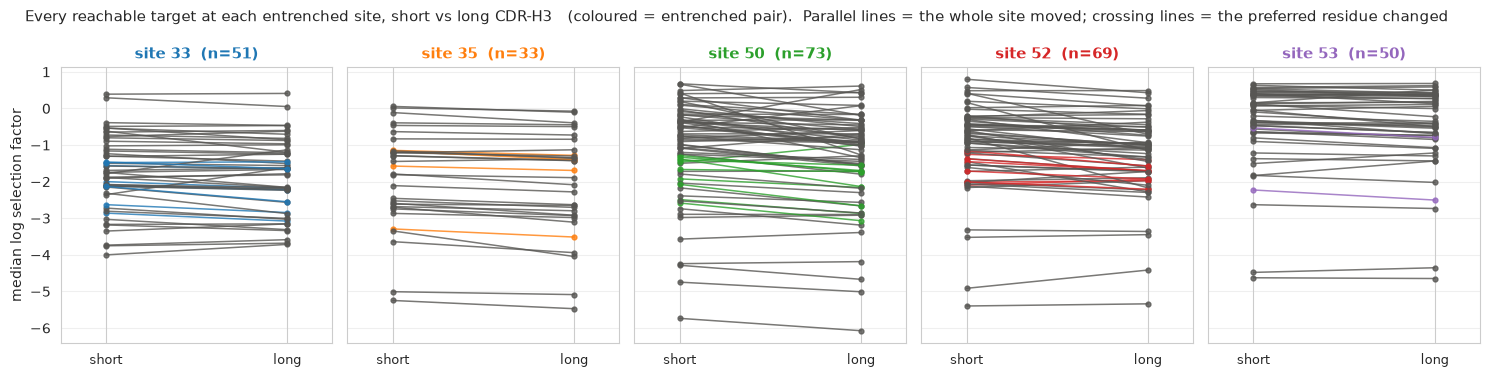

In [10]:
binned = assign_hi_lo(sub_df, "cdr3_length")
fig, axes = plt.subplots(1, len(ENT_SITES), figsize=(15, 3.8), sharey=True)
for ax, site in zip(np.atleast_1d(axes), ENT_SITES):
    d = binned[binned.site == site]
    m = d.groupby(["parent_aa", "selection_factor_target_aa", "hi"],
                  observed=True).log_selection_factor.median().unstack()
    m = m.dropna()
    for (aa, tgt), row in m.iterrows():
        ax.plot([0, 1], [row[0], row[1]], "-o", ms=3.5, lw=1.1, alpha=0.8,
                color=ENTRENCHED_SITE_COLORS.get(site, BLUE)
                if (site, aa, tgt) in WITHIN_PAIRS else GREY_DOT)
    ax.set_xlim(-0.25, 1.25); ax.set_xticks([0, 1])
    ax.set_xticklabels(["short", "long"], fontsize=9)
    ax.set_title(f"site {site}  (n={len(m)})", fontsize=10.5, fontweight="bold",
                 color=ENTRENCHED_SITE_COLORS.get(site, BLUE))
    ax.grid(True, axis="y", alpha=0.3)
np.atleast_1d(axes)[0].set_ylabel("median log selection factor", fontsize=10)
fig.suptitle("Every reachable target at each entrenched site, short vs long CDR-H3   "
             "(coloured = entrenched pair).  Parallel lines = the whole site moved; "
             "crossing lines = the preferred residue changed", fontsize=11, x=0.02, ha="left")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/fig5_interaction_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 5. Is the total conserved? (in IGHV3, largely; in IGHV1, no)

If constraint is redistributed rather than added, the count-weighted class shifts should
cancel and the V-region mean should barely move.

**What this checks.** Whether a long CDR-H3 adds constraint or only moves it around.
**Conclusion.** Pooled, it looks like pure redistribution: the count-weighted class shifts
cancel against the observed global shift. But this is carried by IGHV3. In IGHV1 the rise
at non-contacting sites is close to zero, so there is little to cancel and the
contacting-site tightening stands on its own. Section 5a finds the same split in the
correlation structure. The consequence is favourable for the main claim: IGHV1 shows the
contact effect without any accompanying redistribution, so the effect cannot be an artifact
of a conservation constraint.

per-family GLOBAL mean log SF vs CDR-H3 length: rho=+0.0783 p=2.40e-08
  short -1.9366  mid -1.9064  long -1.9174   GLOBAL delta = +0.0192



POOLED
         class  n_rows   short    long   delta    weighted
    contacting  289980 -1.4858 -1.7024 -0.2165 -62787.6845
non-contacting 1280568 -1.8715 -1.7160  0.1556 199221.8958
    occasional  904050 -2.1843 -2.2849 -0.1005 -90879.9703
  count-weighted sum of class deltas = +0.0184
  observed global delta              = +0.0192

BY V FAMILY -- the cancellation is not general:



IGHV1
         class  n_rows   short    long   delta    weighted
    contacting   89196 -1.5905 -1.7079 -0.1174 -10473.1318
non-contacting  387924 -1.5888 -1.5973 -0.0085  -3301.9952
    occasional  274147 -2.1939 -2.2920 -0.0981 -26889.1879
  count-weighted sum = -0.0541   observed global = -0.0542



IGHV3
         class  n_rows   short    long   delta    weighted
    contacting  200784 -1.4222 -1.6987 -0.2765 -55523.2270
non-contacting  892644 -1.9952 -1.8012  0.1940 173165.9876
    occasional  629903 -2.1849 -2.2729 -0.0880 -55452.0731
  count-weighted sum = +0.0361   observed global = +0.0363


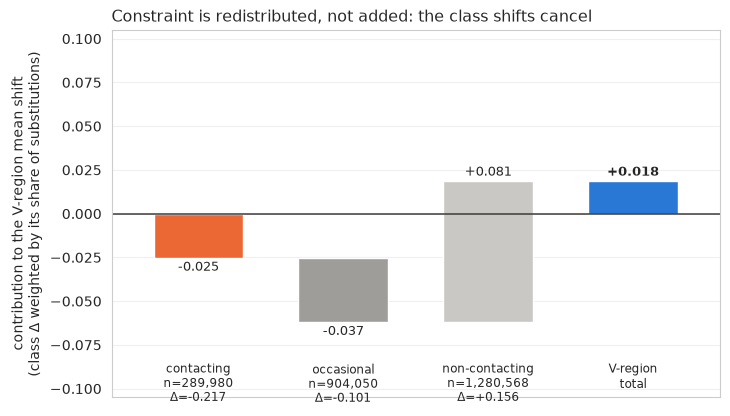

In [11]:
def budget_table(base):
    '''Count-weighted class shifts and the V-region total, for one set of families.'''
    fam_g = base.groupby("family_key").agg(glob=("log_selection_factor", "mean"),
                                           L=("cdr3_length", "first"))
    t3 = fam_g.assign(t=pd.qcut(fam_g.L, 3, labels=["short", "mid", "long"])
                      ).groupby("t", observed=True).glob.mean()
    rows = []
    for cls, g in base.groupby("cls"):
        f = g.groupby("family_key").log_selection_factor.mean().to_frame("v").join(
            fam_g[["L"]])
        tt = f.assign(t=pd.qcut(f.L, 3, labels=["short", "mid", "long"])
                      ).groupby("t", observed=True).v.mean()
        rows.append({"class": cls, "n_rows": len(g), "short": tt["short"],
                     "long": tt["long"], "delta": tt["long"] - tt["short"]})
    b = pd.DataFrame(rows)
    b["weighted"] = b.delta * b.n_rows
    return b, t3["long"] - t3["short"], b.weighted.sum() / b.n_rows.sum()


base = sub_df.dropna(subset=["cdr3_length", "log_selection_factor"]).join(
    classified[["cdr3_contact_freq"]], on="site")
base["contact"] = base.cdr3_contact_freq.fillna(0)
base["cls"] = np.where(base.contact > 0.5, "contacting",
                np.where(base.contact > 0, "occasional", "non-contacting"))
fam_glob = base.groupby("family_key").agg(glob=("log_selection_factor", "mean"),
                                          L=("cdr3_length", "first"))
rho, p = spearmanr(fam_glob.L, fam_glob.glob)
t3 = fam_glob.assign(t=pd.qcut(fam_glob.L, 3, labels=["short", "mid", "long"])
                     ).groupby("t", observed=True).glob.mean()
print(f"per-family GLOBAL mean log SF vs CDR-H3 length: rho={rho:+.4f} p={p:.2e}")
print(f"  short {t3['short']:.4f}  mid {t3['mid']:.4f}  long {t3['long']:.4f}   "
      f"GLOBAL delta = {t3['long']-t3['short']:+.4f}")
bud, global_delta, weighted_sum = budget_table(base)
print("\nPOOLED")
print(bud.round(4).to_string(index=False))
print(f"  count-weighted sum of class deltas = {weighted_sum:+.4f}")
print(f"  observed global delta              = {global_delta:+.4f}")

print("\nBY V FAMILY -- the cancellation is not general:")
for vf in V_FAMILIES:
    b_vf, gd, ws = budget_table(base[base.v_family == vf])
    print(f"\n{vf}")
    print(b_vf.round(4).to_string(index=False))
    print(f"  count-weighted sum = {ws:+.4f}   observed global = {gd:+.4f}")

fig, ax = plt.subplots(figsize=(7.4, 4.3))
order = [c for c in ["contacting", "occasional", "non-contacting"] if c in set(bud["class"])]
b = bud.set_index("class").loc[order]
contrib = b.delta * b.n_rows / bud.n_rows.sum()
cols = {"contacting": ORANGE, "occasional": GREY, "non-contacting": "#c9c8c4"}
run = 0.0
for i, cls in enumerate(order):
    v = contrib[cls]
    ax.bar(i, v, bottom=run, color=cols[cls], width=0.62)
    ax.text(i, run + v + (0.0015 if v > 0 else -0.0015), f"{v:+.3f}", ha="center",
            va="bottom" if v > 0 else "top", fontsize=9.5)
    ax.text(i, -0.085, f"{cls}\nn={b.n_rows[cls]:,}\n$\\Delta$={b.delta[cls]:+.3f}",
            ha="center", va="top", fontsize=8.5)
    run += v
ax.bar(len(order), run, color=BLUE, width=0.62)
ax.text(len(order), run + 0.0015, f"{run:+.3f}", ha="center", va="bottom",
        fontsize=9.5, fontweight="bold")
ax.text(len(order), -0.085, "V-region\ntotal", ha="center", va="top", fontsize=8.5)
ax.axhline(0, color="#3d3c3a", lw=1.1)
ax.set_xticks([]); ax.set_ylim(-0.105, 0.105); ax.set_xlim(-0.6, len(order) + 0.6)
ax.set_ylabel("contribution to the V-region mean shift\n"
              "(class $\\Delta$ weighted by its share of substitutions)", fontsize=10)
ax.set_title("Constraint is redistributed, not added: the class shifts cancel",
             fontsize=11.5, loc="left")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/fig6_budget_waterfall.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 6. Nuisance variables, and whether entrenchment adds anything

`n_subs`, the number of substitutions at a site, is a real nuisance variable: entrenched
sites are the busiest in the dataset because entrenchment requires germline diversity, which
generates substitution units.

**What this checks.** Whether the contact relationship survives the two site-level covariates
that track it, and whether entrenchment adds anything of its own.
**Conclusion.** Contact survives (beta=-13.6, p=5e-07). Substitution count is a real
secondary effect. The entrenched indicator falls from p=0.002 alone to p=0.63 once contact
and substitution count are included.

In [12]:
per_site = LEN.groupby("site").agg(
    shift=("delta", "median"), abs_shift=("abs_delta", "median"), n_subs=("delta", "size"),
    n_fam=("n_families", "median"), iqr=("iqr", "median")).join(
    classified[["cdr3_contact_freq"]]).dropna()
per_site = per_site[per_site.n_subs >= 5]
per_site["ent"] = per_site.index.isin(ENT_SITES).astype(float)
per_site.to_csv(f"{OUTPUT_DIR}/per_site_shift.csv")
print(f"{len(per_site)} sites.  entrenched n_subs: "
      + ", ".join(f"{i}={int(r.n_subs)}" for i, r in per_site[per_site.ent == 1].iterrows())
      + f"   |  median elsewhere = {per_site[per_site.ent==0].n_subs.median():.0f}")
print("\nmarginal Spearman vs per-site shift:")
for c in ["cdr3_contact_freq", "n_subs", "n_fam", "iqr"]:
    rr, pp = spearmanr(per_site[c], per_site["shift"])
    print(f"  {c:20s} rho={rr:+.3f}  p={pp:.2e}")


def rank_ols(y, cols, label):
    X = pd.DataFrame({c: (per_site[c].rank() if c != "ent" else per_site[c]) for c in cols})
    X = (X - X.mean()) / X.std(ddof=0); X.insert(0, "const", 1.0)
    m = OLS(np.asarray(per_site[y].rank(), float), np.asarray(X, float)).fit()
    terms = "   ".join(f"{n}: b={b:+.2f} p={p:.1e}"
                       for n, b, p in zip(X.columns, m.params, m.pvalues) if n != "const")
    print(f"  {label:34s} R2={m.rsquared:.3f}   {terms}")


print("\nrank regressions on the per-site signed shift:")
rank_ols("shift", ["ent"], "~ entrenched")
rank_ols("shift", ["ent", "cdr3_contact_freq"], "~ entrenched + contact")
rank_ols("shift", ["ent", "cdr3_contact_freq", "n_subs"], "~ entrenched + contact + n_subs")
rank_ols("shift", ["ent", "cdr3_contact_freq", "n_subs", "n_fam"], "~ + n_fam")

100 sites.  entrenched n_subs: 33=42, 35=27, 50=63, 52=53, 53=45   |  median elsewhere = 12

marginal Spearman vs per-site shift:
  cdr3_contact_freq    rho=-0.533  p=1.10e-08
  n_subs               rho=-0.405  p=2.96e-05
  n_fam                rho=+0.367  p=1.75e-04
  iqr                  rho=+0.038  p=7.06e-01

rank regressions on the per-site signed shift:
  ~ entrenched                       R2=0.095   ent: b=-8.88 p=1.9e-03
  ~ entrenched + contact             R2=0.302   ent: b=-4.03 p=1.3e-01   cdr3_contact_freq: b=-14.00 p=5.5e-07
  ~ entrenched + contact + n_subs    R2=0.368   ent: b=-1.42 p=5.9e-01   cdr3_contact_freq: b=-12.99 p=1.3e-06   n_subs: b=-8.07 p=2.0e-03
  ~ + n_fam                          R2=0.369   ent: b=-1.32 p=6.2e-01   cdr3_contact_freq: b=-13.19 p=1.8e-06   n_subs: b=-9.31 p=3.5e-02   n_fam: b=-1.51 p=7.3e-01


In [13]:
# The germline-codon filter is applied per site, so it could in principle select families
# non-randomly by CDR-H3 length. It does not: the shift is uniform across the V region
# and unrelated to the per-site result.
gl = aa_v.drop_duplicates(["pcp_index", "site"])[["pcp_index", "site", "is_germline_codon"]]
gl = gl.merge(pcp_df[["pcp_index", "family_key", "cdr3_length"]], on="pcp_index")
gl = gl.drop_duplicates(["family_key", "site"]).dropna(subset=["cdr3_length"])
gl["tert"] = pd.qcut(gl.cdr3_length, 3, labels=["short", "mid", "long"])
ret = gl.pivot_table(index="site", columns="tert", values="is_germline_codon",
                     aggfunc="mean", observed=True)
ret["delta_ret"] = ret["long"] - ret["short"]
ret = ret.join(classified[["cdr3_contact_freq"]]).dropna()
print("germline-state retention (parent still carries the germline codon):")
print(f"  overall  short {gl[gl.tert=='short'].is_germline_codon.mean():.3f}   "
      f"mid {gl[gl.tert=='mid'].is_germline_codon.mean():.3f}   "
      f"long {gl[gl.tert=='long'].is_germline_codon.mean():.3f}")
rr, pp = spearmanr(ret.cdr3_contact_freq, ret.delta_ret)
print(f"  retention change vs contact frequency: rho={rr:+.3f} p={pp:.2f}")
j = ret.join(per_site[["shift"]]).dropna()
rr, pp = spearmanr(j.delta_ret, j["shift"])
print(f"  retention change vs per-site shift:    rho={rr:+.3f} p={pp:.2f}")
print("-> the per-site germline filter does not drive the contact result.")

germline-state retention (parent still carries the germline codon):
  overall  short 0.880   mid 0.859   long 0.853
  retention change vs contact frequency: rho=-0.096 p=0.34
  retention change vs per-site shift:    rho=+0.089 p=0.38
-> the per-site germline filter does not drive the contact result.


### 6a. Is it germline diversity rather than contact?

`n_subs` above is one face of germline diversity; the number of germline amino acids at
the site is the other and the more direct one. Entrenched and CDR-H3-contacting sites are
also the germline-diverse sites, so "contacting sites are more CDR-H3-sensitive" and
"germline-diverse sites are more CDR-H3-sensitive" are hard to tell apart marginally.

Diversity is measured from the germline assignment of every clonal family, not from the
residues that clear `MIN_FAMILIES`: the latter would bake the unit threshold into the
covariate and make it a restatement of `n_subs`. Monomorphic sites are excluded, having
no diversity to stratify on. Both a count and an entropy binning are reported, since the
count ignores how skewed the residue distribution is.

**What this checks.** First, whether germline diversity is even capable of confounding
this -- it would have to be higher at contacting sites *and* positively related to
`|delta|`. Second, whether the contact effect survives within each level of diversity.
**Conclusion.** Printed below, with the per-bin ratios also annotated on the figure.

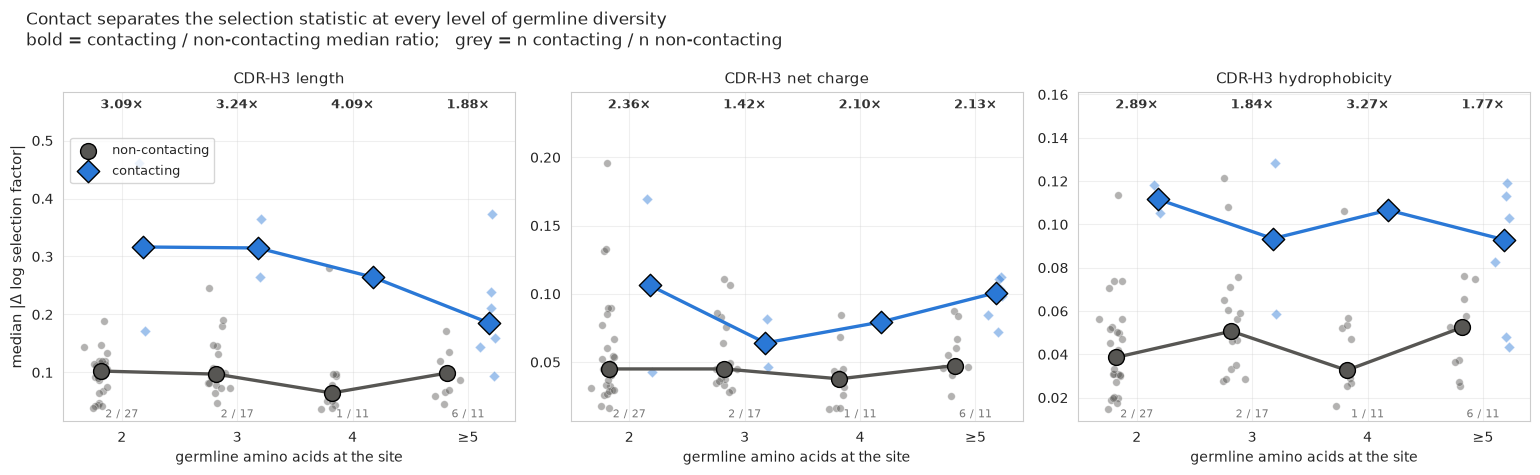

23 monomorphic sites excluded; 77 sites retained

  k        contacting 5.00 vs rest 3.00  (higher at contacting sites, p=0.02);  rho(k, |delta|) = +0.06
  entropy  contacting 0.72 vs rest 0.62  (higher at contacting sites, p=0.51);  rho(entropy, |delta|) = -0.08

-> (a) holds for the count but not for entropy. (b) fails for both: diversity
   is essentially unrelated to |delta| (rho -0.08 to +0.06), so it has no route to inflate the contact contrast,
   whichever way it is measured. The stratification below confirms it directly.

bin                             2     3     4    Q1    Q2    Q3    Q4    ≥5
descriptor          binning                                                
cdr3_charge         entropy   NaN   NaN   NaN  1.14  1.68  1.85  2.01   NaN
                    k        2.36  1.42  2.10   NaN   NaN   NaN   NaN  2.13
cdr3_hydrophobicity entropy   NaN   NaN   NaN  2.12  1.96  2.30  1.98   NaN
                    k        2.89  1.84  3.27   NaN   NaN   NaN   NaN  1.77
cdr3_le

In [14]:
# Germline diversity per site, from the germline assignment of every clonal family in the
# analysis. Deliberately independent of the analysis filters: counting only residues that
# clear MIN_FAMILIES would bake the unit threshold into the covariate and make it close to
# n_subs, which the previous section already controls.
_germ = pd.read_csv(f"germline/germline_codons_{NUMBERING}.csv", dtype={"site": str})
_fam_v = sub_df.drop_duplicates("family_key")[["family_key", "v_gene"]]
_per_family = _germ[_germ.site.isin(set(split.site))].merge(_fam_v, on="v_gene")


def _entropy(x):
    p = x.value_counts(normalize=True)
    return float(-(p * np.log(p)).sum())


diversity = _per_family.groupby("site").amino_acid.agg(
    k="nunique", entropy=_entropy)

# Monomorphic sites carry a single germline amino acid, so they have no germline
# diversity to stratify on and cannot inform this comparison. They are dropped rather
# than folded into the lowest bin -- doing the latter puts sites 3 and 4, the unexplained
# N-terminal pair noted in the caveats, into a bin they do not belong in.
n_mono = int((diversity.k == 1).sum())
K_ORDER = ["2", "3", "4", "≥5"]

fig, axes = plt.subplots(1, len(cu.CDR3_DESCRIPTORS), figsize=(15.5, 4.8))
ratio_rows = []
for ax, desc in zip(axes, cu.CDR3_DESCRIPTORS):
    g = (split[split.descriptor == desc]
         .groupby("site").agg(y=("abs_delta", "median"), n_subs=("delta", "size"),
                              contact=("contact", "first"))
         .join(diversity))
    g = g[(g.n_subs >= 5) & (g.k >= 2)].copy()
    g["c"] = g.contact > 0.5
    g["kb"] = pd.cut(g.k, [1, 2, 3, 4, np.inf], labels=K_ORDER)
    g["eq"] = pd.qcut(g.entropy, 4, labels=["Q1", "Q2", "Q3", "Q4"])

    for lab, mask, colour, mk in [("non-contacting", ~g.c, GREY_DOT, "o"),
                                  ("contacting", g.c, BLUE, "D")]:
        sub, off = g[mask], (0.18 if lab == "contacting" else -0.18)
        xs = np.array([K_ORDER.index(str(b)) for b in sub.kb]) + off
        ax.scatter(xs + np.random.default_rng(1).normal(0, 0.055, len(xs)), sub.y,
                   s=30, c=colour, marker=mk, alpha=0.45, edgecolor="white", lw=0.5,
                   zorder=2)
        med = sub.groupby("kb", observed=True).y.median().reindex(K_ORDER)
        xm = [K_ORDER.index(b) + off for b in K_ORDER]
        ax.plot(xm, med.values, "-", color=colour, lw=2.4, zorder=3)
        ax.scatter(xm, med.values, s=130, c=colour, marker=mk, edgecolor="black",
                   lw=1.0, zorder=4, label=lab)

    for bincol, binname, order in [("kb", "k", K_ORDER),
                                   ("eq", "entropy", ["Q1", "Q2", "Q3", "Q4"])]:
        t = g.pivot_table(index=bincol, columns="c", values="y", aggfunc="median",
                          observed=True)
        n = g.groupby(bincol, observed=True).c.agg(["sum", "size"]).reindex(order)
        for b in order:
            ratio_rows.append({
                "descriptor": desc, "binning": binname, "bin": b,
                "ratio": t.loc[b, True] / t.loc[b, False],
                "n_contacting": int(n.loc[b, "sum"]),
                "n_rest": int(n.loc[b, "size"] - n.loc[b, "sum"])})

    lo, hi = ax.get_ylim()
    ax.set_ylim(lo, hi + 0.22 * (hi - lo))
    kt = g.pivot_table(index="kb", columns="c", values="y", aggfunc="median",
                       observed=True)
    kn = g.groupby("kb", observed=True).c.agg(["sum", "size"]).reindex(K_ORDER)
    for i, b in enumerate(K_ORDER):
        ax.annotate(f"{kt.loc[b, True] / kt.loc[b, False]:.2f}×",
                    (i, ax.get_ylim()[1]), xytext=(0, -12), textcoords="offset points",
                    ha="center", fontsize=9, fontweight="bold", color="#333")
        ax.annotate(f"{int(kn.loc[b, 'sum'])} / {int(kn.loc[b, 'size'] - kn.loc[b, 'sum'])}",
                    (i, lo), xytext=(0, 3), textcoords="offset points", ha="center",
                    fontsize=8, color="#777")
    ax.set_xticks(range(len(K_ORDER)))
    ax.set_xticklabels(K_ORDER)
    ax.set_xlabel("germline amino acids at the site", fontsize=10)
    ax.set_title(LAB[desc], fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("median |$\\Delta$ log selection factor|", fontsize=10.5)
axes[0].legend(fontsize=9.5, loc="upper left", bbox_to_anchor=(0.0, 0.88))
fig.suptitle("Contact separates the selection statistic at every level of germline "
             "diversity\nbold = contacting / non-contacting median ratio;   "
             "grey = n contacting / n non-contacting", fontsize=12.5, x=0.02, ha="left")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/fig_selection_by_k.pdf", dpi=300, bbox_inches="tight")
plt.show()

by_div = pd.DataFrame(ratio_rows)
by_div.to_csv(f"{OUTPUT_DIR}/contact_ratio_by_diversity.csv", index=False)

# Whether diversity could confound this at all: it would have to be higher at contacting
# sites AND positively related to |delta|. Both are checked here.
D = (split[split.descriptor == "cdr3_length"]
     .groupby("site").agg(y=("abs_delta", "median"), n_subs=("delta", "size"),
                          contact=("contact", "first")).join(diversity))
D = D[(D.n_subs >= 5) & (D.k >= 2)]
D["c"] = D.contact > 0.5
print(f"{n_mono} monomorphic sites excluded; {len(D)} sites retained\n")
# To confound, diversity must be (a) higher at contacting sites AND (b) positively
# related to |delta|. Report both and let the numbers state which leg fails.
rhos = {}
for col in ["k", "entropy"]:
    mw = mannwhitneyu(D.loc[D.c, col], D.loc[~D.c, col]).pvalue
    rhos[col] = spearmanr(D[col], D.y)[0]
    higher = "higher" if D.loc[D.c, col].median() > D.loc[~D.c, col].median() else "lower"
    print(f"  {col:8s} contacting {D.loc[D.c, col].median():.2f} vs rest "
          f"{D.loc[~D.c, col].median():.2f}  ({higher} at contacting sites, p={mw:.2f});"
          f"  rho({col}, |delta|) = {rhos[col]:+.2f}")
print(f"\n-> (a) holds for the count but not for entropy. (b) fails for both: diversity")
print(f"   is essentially unrelated to |delta| (rho {min(rhos.values()):+.2f} to "
      f"{max(rhos.values()):+.2f}), so it has no route to inflate the contact contrast,")
print("   whichever way it is measured. The stratification below confirms it directly.\n")
print(by_div.pivot_table(index=["descriptor", "binning"], columns="bin",
                         values="ratio").round(2).to_string())
print(f"\ncontact ratio above 1 in {(by_div.ratio > 1).sum()} of {len(by_div)} "
      f"(descriptor x binning x bin) cells")

## 7. Model-free: does a longer CDR-H3 actually bury these sites more?

No DASM here. For each SAbDab structure we take its own CDR-H3 length (residues in the
95--102 window) and ask whether burial at each V-region site rises with it. RSA has no
normalisation across residues, so the compositional caveats of Sections 4--5 do not apply.

**What this checks.** Whether a longer CDR-H3 physically buries these sites more, using
crystal structures alone.
**Conclusion.** Yes, and this is the strongest result here: burial rises with the structure's
own CDR-H3 length at all five entrenched sites (rho 0.21-0.46, all p<1e-10) against ~+0.05
elsewhere. It gives the DASM result an independent structural basis.

In [15]:
# CDR-H3 length per structure = residues in the 95-102 window, from the UNFILTERED frame
_n = sa_all.assign(n=sa_all.site.map(cu.site_number))
cdr3_len = _n[(_n.n >= 95) & (_n.n <= 102)].groupby("pdb_id").size().rename("cdr3_len")
assert len(cdr3_len) > 0, "no structures with residues in the 95-102 window"
print(f"{len(cdr3_len):,} structures; CDR-H3 length median {cdr3_len.median():.0f}, "
      f"range {cdr3_len.min()}-{cdr3_len.max()}")
sv = sa_b.join(cdr3_len, on="pdb_id").dropna(subset=["cdr3_len"])

rows = []
for site, g in sv.groupby("site"):
    if g.pdb_id.nunique() < 30 or g.burial_by_vdj_junction.nunique() < 2:
        continue                      # constant burial -> correlation undefined
    rho, pv = spearmanr(g.cdr3_len, g.burial_by_vdj_junction)
    lo = g[g.cdr3_len <= g.cdr3_len.quantile(1/3)]
    hi = g[g.cdr3_len >= g.cdr3_len.quantile(2/3)]
    rows.append({"site": site, "n_struct": g.pdb_id.nunique(), "rho": rho, "p": pv,
                 "burial_short": lo.burial_by_vdj_junction.mean(),
                 "burial_long": hi.burial_by_vdj_junction.mean(),
                 "d_burial": hi.burial_by_vdj_junction.mean()
                             - lo.burial_by_vdj_junction.mean()})
struct = pd.DataFrame(rows).set_index("site")
struct["entrenched"] = struct.index.isin(ENT_SITES)
struct.to_csv(f"{OUTPUT_DIR}/structural_burial_vs_cdr3_length.csv")
print("\nentrenched sites:")
print(struct[struct.entrenched][["n_struct", "rho", "p", "burial_short", "burial_long",
                                 "d_burial"]].round(4).to_string())
print(f"\n{len(struct)} sites with defined rho: median {struct.rho.median():+.3f}; "
      f"entrenched {struct[struct.entrenched].rho.median():+.3f} vs others "
      f"{struct[~struct.entrenched].rho.median():+.3f}  (MW p="
      f"{mannwhitneyu(struct[struct.entrenched].d_burial, struct[~struct.entrenched].d_burial, alternative='greater').pvalue:.4f})")
print("\ntop 10 sites by rho:")
print(struct.nlargest(10, "rho")[["n_struct", "rho", "d_burial", "entrenched"]]
      .round(4).to_string())

1,778 structures; CDR-H3 length median 13, range 2-31

entrenched sites:
      n_struct     rho    p  burial_short  burial_long  d_burial
site                                                            
33        1775  0.3712  0.0        0.1718       0.2462    0.0744
35        1778  0.2208  0.0        0.1570       0.1821    0.0251
50        1778  0.2108  0.0        0.0481       0.0836    0.0355
52        1771  0.4142  0.0        0.0289       0.0921    0.0631
53        1776  0.4556  0.0        0.0045       0.0628    0.0583

52 sites with defined rho: median +0.068; entrenched +0.371 vs others +0.045  (MW p=0.0004)

top 10 sites by rho:
      n_struct     rho  d_burial  entrenched
site                                        
31        1769  0.5125    0.1253       False
53        1776  0.4556    0.0583        True
52        1771  0.4142    0.0631        True
33        1775  0.3712    0.0744        True
32        1775  0.3698    0.0644       False
31A         40  0.3490    0.0889       Fal

DASM per-site shift vs structural rho: -0.320 p=2.20e-02 (n=51)
structural rho vs contact frequency:   +0.431 p=1.61e-03
(the two structural measures are correlated, so they cannot be separated here)


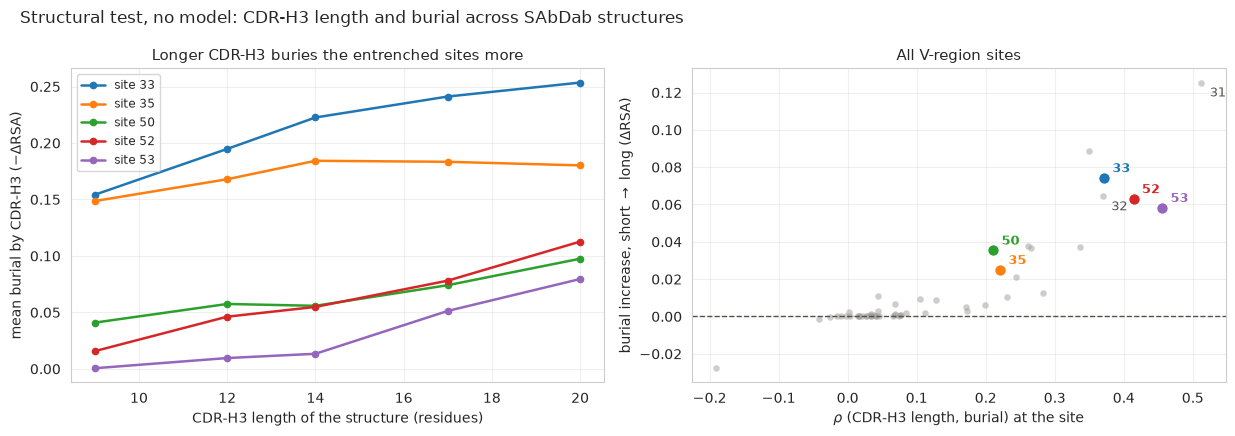

In [16]:
coh = per_site.join(struct[["rho", "d_burial"]]).dropna()
r1, p1 = spearmanr(coh.rho, coh["shift"])
print(f"DASM per-site shift vs structural rho: {r1:+.3f} p={p1:.2e} (n={len(coh)})")
r2, p2 = spearmanr(coh.rho, coh.cdr3_contact_freq)
print(f"structural rho vs contact frequency:   {r2:+.3f} p={p2:.2e}")
print("(the two structural measures are correlated, so they cannot be separated here)")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax = axes[0]
for site, g in sv[sv.site.isin(ENT_SITES)].groupby("site"):
    b = g.groupby(pd.qcut(g.cdr3_len, 5, duplicates="drop"), observed=True).agg(
        x=("cdr3_len", "median"), y=("burial_by_vdj_junction", "mean"))
    ax.plot(b.x, b.y, "-o", ms=4.5, lw=1.8,
            color=ENTRENCHED_SITE_COLORS.get(site, BLUE), label=f"site {site}")
ax.set_xlabel("CDR-H3 length of the structure (residues)", fontsize=10)
ax.set_ylabel("mean burial by CDR-H3 ($-\\Delta$RSA)", fontsize=10)
ax.set_title("Longer CDR-H3 buries the entrenched sites more", fontsize=11)
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.axhline(0, color="#52514e", lw=1, ls="--")
ne = ~struct.entrenched
ax.scatter(struct.loc[ne, "rho"], struct.loc[ne, "d_burial"], s=22, c=GREY, alpha=0.5, lw=0)
for site, r in struct[struct.entrenched].iterrows():
    ax.scatter([r.rho], [r.d_burial], s=70, color=ENTRENCHED_SITE_COLORS.get(site, BLUE),
               edgecolor="white", lw=0.9, zorder=5)
    ax.annotate(site, (r.rho, r.d_burial), xytext=(6, 4), textcoords="offset points",
                fontsize=9.5, fontweight="bold",
                color=ENTRENCHED_SITE_COLORS.get(site, BLUE))
for site in ["31", "32"]:
    if site in struct.index:
        r = struct.loc[site]
        ax.annotate(site, (r.rho, r.d_burial), xytext=(6, -10),
                    textcoords="offset points", fontsize=9, color="#52514e")
ax.set_xlabel("$\\rho$ (CDR-H3 length, burial) at the site", fontsize=10)
ax.set_ylabel("burial increase, short $\\to$ long ($\\Delta$RSA)", fontsize=10)
ax.set_title("All V-region sites", fontsize=11); ax.grid(True, alpha=0.3)
fig.suptitle("Structural test, no model: CDR-H3 length and burial across SAbDab structures",
             fontsize=12.5, x=0.02, ha="left")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/fig7_structural_burial.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 8. The test: does contact predict the size of the CDR-H3 effect?

One inferential test for the whole notebook; everything above is descriptive or visual.

Two choices make it defensible. **The unit is a (site, V family) pair**, because
substitutions at a site share families and share the site-level shift, so they cannot be
counted as independent. IGHV1 and IGHV3 are kept separate: they are disjoint sets of clonal
families, entrenchment is called per family, and each gets its own contact frequency from
its own structures.

And **contact is binary**. The contact frequencies are bimodal with an empty band from 0.35
to 0.51, and sites contacted only occasionally behave like sites never contacted, so the
split follows a discontinuity in the data rather than imposing one. Because the relationship
is a step rather than a slope, a rank correlation on contact frequency is weak while the
step is not.

**What this checks.** Whether CDR-H3 composition perturbs selection more at sites the CDR-H3
contacts, pooling IGHV1 and IGHV3.
**Conclusion.** Yes for all three descriptors, and separately in each V family.

In [17]:
# contact frequency computed within each V family, from that family's own structures
contact_by_family = {vf: cu.classify_sites(cu.cdr3_burial_by_site(v_families=(vf,)),
                                           NUMBERING).cdr3_contact_freq
                     for vf in V_FAMILIES}

unit_rows = []
for vf in V_FAMILIES:
    d_vf = sub_df[sub_df.v_family == vf]
    for desc in cu.CDR3_DESCRIPTORS:
        u = binary_deltas(d_vf, desc, pairs=WITHIN_PAIRS_BY_FAMILY[vf])
        u = u.groupby("site").abs_delta.median().to_frame("absd")
        u["contact"] = contact_by_family[vf].reindex(u.index).fillna(0)
        u["v_family"], u["descriptor"] = vf, desc
        unit_rows.append(u.reset_index())
units = pd.concat(unit_rows, ignore_index=True)     # one row per (site, V family)

rows = []
for desc in cu.CDR3_DESCRIPTORS:
    for scope in V_FAMILIES + ["pooled"]:
        u = units[units.descriptor == desc]
        u = u if scope == "pooled" else u[u.v_family == scope]
        c, rest = u[u.contact > 0.5], u[u.contact <= 0.5]
        rows.append({
            "descriptor": desc, "scope": scope,
            "n_contacting": len(c), "n_rest": len(rest),
            "median_abs_contacting": c.absd.median(),
            "median_abs_rest": rest.absd.median(),
            "ratio": c.absd.median() / rest.absd.median(),
            "mannwhitney_p": mannwhitneyu(c.absd, rest.absd,
                                          alternative="greater").pvalue})
site_test = pd.DataFrame(rows)
site_test.to_csv(f"{OUTPUT_DIR}/site_level_magnitude_test.csv", index=False)
for desc in cu.CDR3_DESCRIPTORS:
    print(f"\n=== {desc} ===")
    print(site_test[site_test.descriptor == desc].drop(columns="descriptor")
          .round(4).to_string(index=False))
print("\nIGHV1 and IGHV3 are independent replicates: disjoint families, family-specific")
print("entrenchment calls, and contact frequencies from that family's own structures. The")
print("pooled rows nest two units per site, so their p-values are mildly optimistic; the")
print("per-family rows are the conservative read.")
print("\nWithout clustering (every substitution as its own unit) the same contrast gives")
print("p ~ 1e-13 to 1e-26. Those values assume 1,530 independent units and are not")
print("defensible: three sites supply over half the contacting substitutions.")


=== cdr3_length ===
 scope  n_contacting  n_rest  median_abs_contacting  median_abs_rest  ratio  mannwhitney_p
 IGHV1            13      85                 0.1645           0.0710 2.3157         0.0013
 IGHV3            12      88                 0.2570           0.1090 2.3586         0.0002
pooled            25     173                 0.2115           0.0878 2.4076         0.0000

=== cdr3_charge ===
 scope  n_contacting  n_rest  median_abs_contacting  median_abs_rest  ratio  mannwhitney_p
 IGHV1            13      85                 0.0769           0.0457 1.6843         0.0040
 IGHV3            12      88                 0.0921           0.0569 1.6196         0.0150
pooled            25     173                 0.0851           0.0495 1.7183         0.0003

=== cdr3_hydrophobicity ===
 scope  n_contacting  n_rest  median_abs_contacting  median_abs_rest  ratio  mannwhitney_p
 IGHV1            13      85                 0.0952           0.0374 2.5472         0.0017
 IGHV3            1

## 9. Summary

In [18]:
print(f"MEDIAN SPLIT, {len(LEN):,} substitutions over {LEN.site.nunique()} V-region sites\n")
print("signed (direction):")
print(sign_table[sign_table.descriptor == "cdr3_length"][
    ["group", "n", "pct_down", "median_delta", "median_abs"]].round(4).to_string(index=False))
print("\nmagnitude, site level (the test):")
print(site_test.round(4).to_string(index=False))
print(f"\nresidue-specific after centering: entrenched {e_cen:+.3f} (vs {e_raw:+.3f} raw)")
print(f"structural (no model): entrenched rho "
      f"{struct[struct.entrenched].rho.min():.2f}-{struct[struct.entrenched].rho.max():.2f}, "
      f"all p<1e-10")

MEDIAN SPLIT, 1,530 substitutions over 100 V-region sites

signed (direction):
                 group    n  pct_down  median_delta  median_abs
            entrenched   29   93.1034       -0.2215      0.2335
            all others 1501   52.8981       -0.0080      0.1035
    others, contacting  273   76.1905       -0.1673      0.1959
    others, occasional  633   58.6098       -0.0222      0.0939
others, non-contacting  595   36.1345        0.0394      0.0908

magnitude, site level (the test):
         descriptor  scope  n_contacting  n_rest  median_abs_contacting  median_abs_rest  ratio  mannwhitney_p
        cdr3_length  IGHV1            13      85                 0.1645           0.0710 2.3157         0.0013
        cdr3_length  IGHV3            12      88                 0.2570           0.1090 2.3586         0.0002
        cdr3_length pooled            25     173                 0.2115           0.0878 2.4076         0.0000
        cdr3_charge  IGHV1            13      85          

### Caveats

- These are DASM outputs. DASM applies no normalisation across amino acids or across the
  sequence (`selection_factors_of_aa_idxs` returns the raw model output), so the observed
  near-cancellation is not architecturally forced; the likeliest source is branch-length
  optimisation during training, which pins total substitution probability per pair. A
  neutral-model artifact is not excluded either, since selection factors are defined relative
  to SHM rates and CDR-H3 length changes a sequence's k-mer composition.
- Sites 93 and 94 are adjacent to the CDR-H3 *in sequence*, so their signal may be proximity
  rather than structure. Sites 32, 33, 35, 50 and 52 are far apart in sequence and close only
  in three dimensions, which is the informative case.
- Sites 2, 3 and 4 are frequently contacted but shift *upward*; they are consecutive
  N-terminal residues, so this looks regional rather than random, and it is unexplained.
  They are monomorphic, so they drop out of the germline-diversity stratification in 6a.
- **Site 53 separates from the other four entrenched sites** on solvent exposure (0.456 vs
  0.03--0.14), CDR-H3 contact (0.25 vs 0.51--0.99), `frac_favored` (0.469 vs 0.03--0.28) and
  germline-state retention, and is worth resolving before the result is leaned on.
- Substitution count is a genuine nuisance variable that dividing by the IQR does not remove.